## 1. Imports
Load the libraries required for data preparation, modeling, and evaluation.

In [16]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Data Loading
Read the Helsinki population and EV station datasets and prepare the analysis district list.

In [17]:
# Data loading

def load_data(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load the Helsinki population and EV station datasets from disk."""
    pop_path = data_dir / "population dataset of helsinki_2018_2030.csv"
    stations_path = data_dir / "helsinki_ev_stations.csv"
    df_pop_local = pd.read_csv(pop_path, sep=";", encoding="latin-1")
    df_stations_local = pd.read_csv(stations_path, encoding="latin-1")
    return df_pop_local, df_stations_local


def build_model_frame(df_pop_local: pd.DataFrame, districts_local: list[str]) -> pd.DataFrame:
    """Filter the population data to district totals used for modeling."""
    pop_cols = ["2018", "2022", "2030"]
    df_filtered = df_pop_local.copy()

    for column in pop_cols:
        df_filtered[column] = pd.to_numeric(df_filtered[column], errors="coerce")

    mask = df_filtered["Alue/District"].isin(districts_local) & df_filtered["Ikä/Age"].str.contains("Total", na=False)
    df_model_local = df_filtered.loc[mask, ["Alue/District", *pop_cols]].dropna().copy()
    return df_model_local


data_dir = Path("..") / "dataSet"
districts = [
    "091 1 Eteläinen suurpiiri",
    "091 2 Läntinen suurpiiri",
    "091 3 Keskinen suurpiiri",
    "091 4 Pohjoinen suurpiiri",
    "091 5 Koillinen suurpiiri",
    "091 6 Kaakkoinen suurpiiri",
    "091 7 Itäinen suurpiiri",
]

df_pop, df_stations = load_data(data_dir)
df_model = build_model_frame(df_pop, districts)
df_model

,Alue/District,2018,2022,2030
37,091 1 Eteläinen suurpiiri,116443.0,123482.0,133088.0
1073,091 2 Läntinen suurpiiri,109306.0,114179.0,122040.0
2294,091 3 Keskinen suurpiiri,92618.0,100462.0,116299.0
3441,091 4 Pohjoinen suurpiiri,43112.0,44439.0,51154.0
4144,091 5 Koillinen suurpiiri,99765.0,101841.0,106731.0
5180,091 6 Kaakkoinen suurpiiri,51407.0,56990.0,68179.0
5920,091 7 Itäinen suurpiiri,112012.0,115202.0,120276.0


## 3. Feature Engineering
Create the regression and classification targets, plus growth velocity, from the population data.

In [18]:
# Feature engineering

def add_engineered_features(df_model_local: pd.DataFrame) -> pd.DataFrame:
    """Create demand, growth, and infrastructure target features."""
    df_features = df_model_local.copy()
    df_features["Growth_Rate_18_22"] = np.where(
        df_features["2018"] > 0,
        ((df_features["2022"] - df_features["2018"]) / df_features["2018"]) * 100,
        np.nan,
    )
    df_features["Power_Demand_kW"] = (df_features["2030"] / 100) * 22
    df_features["Infra_Class"] = (df_features["2030"] > 100000).astype(int)
    return df_features.dropna().copy()


df_model = add_engineered_features(df_model)
df_model

,Alue/District,2018,2022,2030,Growth_Rate_18_22,Power_Demand_kW,Infra_Class
37,091 1 Eteläinen suurpiiri,116443.0,123482.0,133088.0,6.045018,29279.36,1
1073,091 2 Läntinen suurpiiri,109306.0,114179.0,122040.0,4.458127,26848.80,1
2294,091 3 Keskinen suurpiiri,92618.0,100462.0,116299.0,8.469196,25585.78,1
3441,091 4 Pohjoinen suurpiiri,43112.0,44439.0,51154.0,3.078029,11253.88,0
4144,091 5 Koillinen suurpiiri,99765.0,101841.0,106731.0,2.080890,23480.82,1
5180,091 6 Kaakkoinen suurpiiri,51407.0,56990.0,68179.0,10.860389,14999.38,0
5920,091 7 Itäinen suurpiiri,112012.0,115202.0,120276.0,2.847909,26460.72,1


## 4. Train-Test Split
Separate the features and targets, then split the data for training and testing.

In [19]:
# Prepare features and targets
feature_cols = ["2018", "2022", "Growth_Rate_18_22"]
X = df_model[feature_cols]
y_reg = df_model["Power_Demand_kW"]
y_clf = df_model["Infra_Class"]

# Split data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

## 5. Regression Model
Train a scaled linear regression model and inspect residuals for non-linear patterns.

Regression R2 Score: 0.75


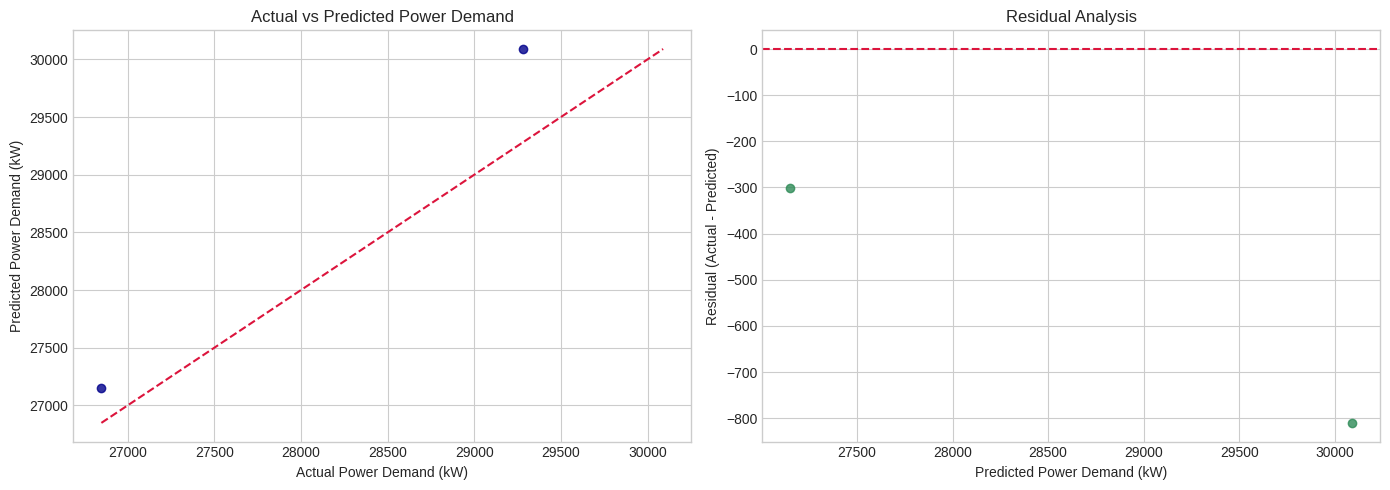

In [20]:
# Regression model

def train_scaled_regression_model(X_train: pd.DataFrame, y_train: pd.Series) -> Pipeline:
    """Train a scaled linear regression model."""
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("regressor", LinearRegression()),
        ]
    )
    model.fit(X_train, y_train)
    return model


def plot_regression_diagnostics(y_true: pd.Series, y_pred: np.ndarray) -> None:
    """Plot prediction fit and residuals to diagnose regression performance."""
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_true, y_pred, color="darkblue", alpha=0.8)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], color="crimson", linestyle="--")
    axes[0].set_title("Actual vs Predicted Power Demand")
    axes[0].set_xlabel("Actual Power Demand (kW)")
    axes[0].set_ylabel("Predicted Power Demand (kW)")

    axes[1].scatter(y_pred, residuals, color="seagreen", alpha=0.8)
    axes[1].axhline(0, color="crimson", linestyle="--")
    axes[1].set_title("Residual Analysis")
    axes[1].set_xlabel("Predicted Power Demand (kW)")
    axes[1].set_ylabel("Residual (Actual - Predicted)")

    plt.tight_layout()
    plt.show()


reg_model = train_scaled_regression_model(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)
print(f"Regression R2 Score: {reg_model.score(X_test_r, y_test_r):.2f}")
plot_regression_diagnostics(y_test_r, y_pred_r)

## 6. Classification Model
Train the decision tree classifier and evaluate it on the held-out test set.

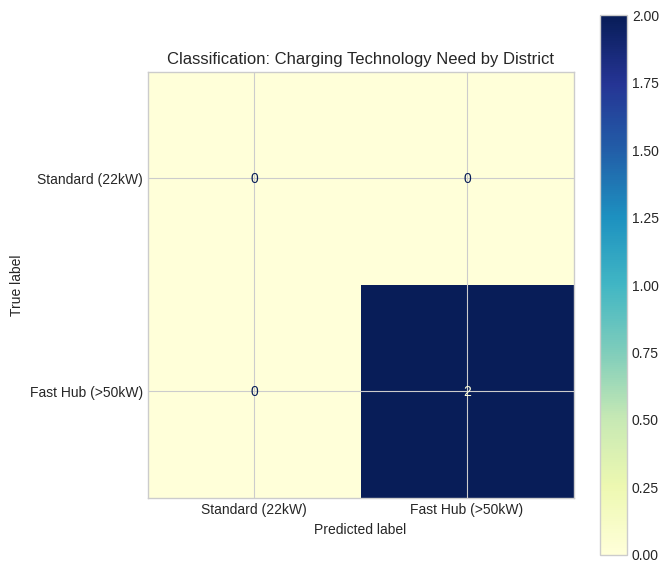


Classification Performance:
                  precision    recall  f1-score   support

 Standard (22kW)       0.00      0.00      0.00         0
Fast Hub (>50kW)       1.00      1.00      1.00         2

        accuracy                           1.00         2
       macro avg       0.50      0.50      0.50         2
    weighted avg       1.00      1.00      1.00         2



In [21]:
# Classification model

def train_classification_model(X_train: pd.DataFrame, y_train: pd.Series) -> DecisionTreeClassifier:
    """Train a decision tree classifier for charging infrastructure selection."""
    model = DecisionTreeClassifier(max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    return model


clf_model = train_classification_model(X_train_c, y_train_c)
y_pred_c = clf_model.predict(X_test_c)

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    clf_model,
    X_test_c,
    y_test_c,
    labels=[0, 1],
    display_labels=["Standard (22kW)", "Fast Hub (>50kW)"],
    cmap="YlGnBu",
    ax=ax,
)
ax.set_title("Classification: Charging Technology Need by District")
plt.tight_layout()
plt.show()

print("\nClassification Performance:")
print(classification_report(y_test_c, y_pred_c, labels=[0, 1], target_names=["Standard (22kW)", "Fast Hub (>50kW)"], zero_division=0))

## 7. Improved EV Demand Calculation
Use the vehicle registry and station supply data for a stronger city-level charging analysis.

City-level supply and demand summary:
                        metric        value
      Helsinki vehicle records  4446.000000
      Charging station records   240.000000
                   Total plugs  1628.000000
22 kW-equivalent plug capacity  2971.363636
            Total demand units 18688.245000
         Supply / demand ratio     0.158996

Vehicle demand by class:
                vehicle_count    mean_co2  mean_age_years  demand_units
ajoneuvoluokka                                                         
M1                       4043  178.657433       24.279248   16937.01325
N1                        321  175.180685       25.766355    1377.04400
M1G                        82  234.414634       22.207317     374.18775

Station supply by power band:
power_band  station_count  plug_count  total_power_kw
  AC 22 kW            197        1412          4169.0
  DC 50 kW             14          57           700.0
   Fast DC             29         159          6080.0


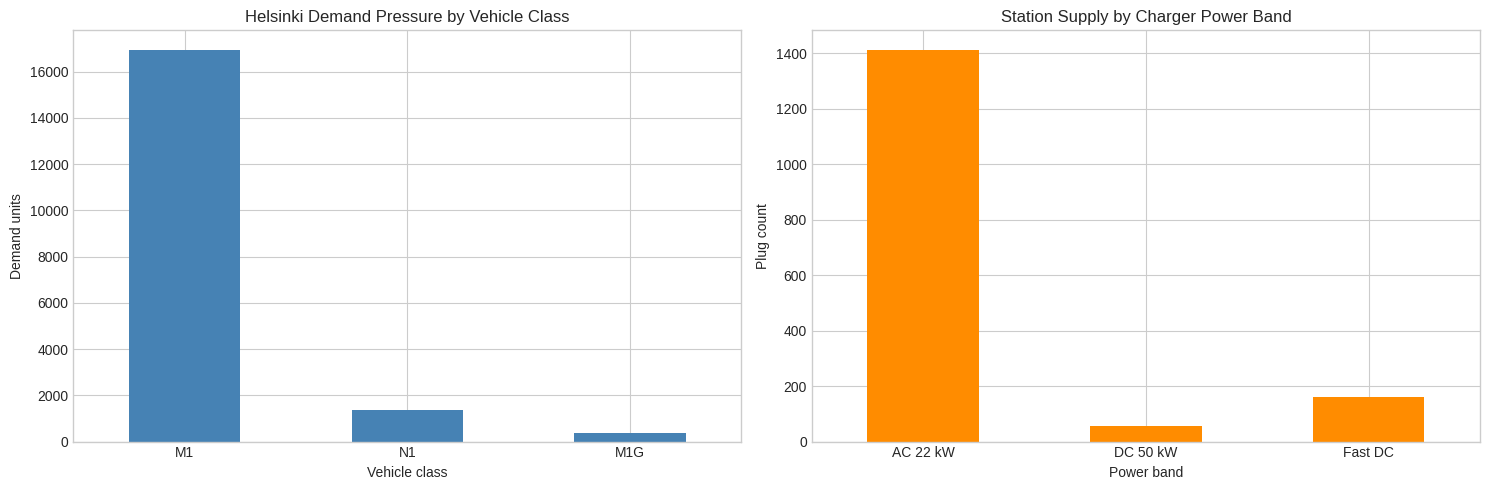

In [22]:
# Improved demand calculation using vehicle and station data

def parse_connector_count(value: str) -> int:
    """Return the number of plugs described in the connectors field."""
    if pd.isna(value):
        return 0
    return sum(int(match) for match in re.findall(r"\((\d+)\)", str(value)))


def parse_power_kw(value: str) -> float:
    """Extract the station power rating in kW from a text field."""
    if pd.isna(value):
        return np.nan
    match = re.search(r"(\d+(?:\.\d+)?)", str(value))
    return float(match.group(1)) if match else np.nan


def build_supply_demand_summary(
    data_dir: Path,
    station_frame: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Build vehicle demand and charging supply summaries for Helsinki."""
    vehicle_path = data_dir / "Vehicles in helsinki area.csv"
    df_vehicle = pd.read_csv(vehicle_path, encoding="latin-1", low_memory=False)

    df_vehicle["kunta"] = pd.to_numeric(df_vehicle["kunta"], errors="coerce")
    df_vehicle["Co2"] = pd.to_numeric(df_vehicle["Co2"], errors="coerce")
    df_vehicle["registration_year"] = pd.to_datetime(
        df_vehicle["ensirekisterointipvm"], errors="coerce"
    ).dt.year

    reference_year = pd.Timestamp.now().year
    df_vehicle["vehicle_age"] = (reference_year - df_vehicle["registration_year"]).clip(lower=0)
    df_vehicle["vehicle_age"] = df_vehicle["vehicle_age"].fillna(df_vehicle["vehicle_age"].median())

    # Keep the vehicle classes that are most relevant for public charging demand.
    df_helsinki = df_vehicle[
        (df_vehicle["kunta"] == 91)
        & df_vehicle["ajoneuvoluokka"].isin(["M1", "M1G", "N1"])
    ].copy()
    df_helsinki["Co2"] = df_helsinki["Co2"].fillna(df_helsinki["Co2"].median())
    df_helsinki["demand_units"] = (1 + df_helsinki["Co2"] / 200.0) * (1 + df_helsinki["vehicle_age"] / 20.0)

    vehicle_summary = (
        df_helsinki.groupby("ajoneuvoluokka")
        .agg(
            vehicle_count=("ajoneuvoluokka", "size"),
            mean_co2=("Co2", "mean"),
            mean_age_years=("vehicle_age", "mean"),
            demand_units=("demand_units", "sum"),
        )
        .sort_values("demand_units", ascending=False)
    )

    station_summary = station_frame.copy()
    station_summary["connector_count"] = station_summary["Connectors"].apply(parse_connector_count)
    station_summary["power_kw"] = station_summary["Power"].apply(parse_power_kw)
    station_summary["power_band"] = pd.cut(
        station_summary["power_kw"],
        bins=[0, 22, 50, np.inf],
        labels=["AC 22 kW", "DC 50 kW", "Fast DC"],
        include_lowest=True,
    )

    supply_summary = (
        station_summary.groupby("power_band", observed=False)
        .agg(
            station_count=("Address", "size"),
            plug_count=("connector_count", "sum"),
            total_power_kw=("power_kw", "sum"),
        )
        .reset_index()
        .sort_values("power_band")
    )

    total_demand_units = float(df_helsinki["demand_units"].sum())
    total_plugs = int(station_summary["connector_count"].sum())
    standard_equiv_plugs = float((station_summary["connector_count"] * station_summary["power_kw"] / 22.0).sum())

    city_summary = pd.DataFrame(
        {
            "metric": [
                "Helsinki vehicle records",
                "Charging station records",
                "Total plugs",
                "22 kW-equivalent plug capacity",
                "Total demand units",
                "Supply / demand ratio",
            ],
            "value": [
                len(df_helsinki),
                len(station_summary),
                total_plugs,
                standard_equiv_plugs,
                total_demand_units,
                standard_equiv_plugs / total_demand_units if total_demand_units else np.nan,
            ],
        }
    )

    return vehicle_summary, supply_summary, city_summary


vehicle_summary, supply_summary, city_summary = build_supply_demand_summary(data_dir, df_stations)

print("City-level supply and demand summary:")
print(city_summary.to_string(index=False))
print("\nVehicle demand by class:")
print(vehicle_summary.to_string())
print("\nStation supply by power band:")
print(supply_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
vehicle_summary["demand_units"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Helsinki Demand Pressure by Vehicle Class")
axes[0].set_xlabel("Vehicle class")
axes[0].set_ylabel("Demand units")
axes[0].tick_params(axis="x", rotation=0)

supply_summary.set_index("power_band")["plug_count"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Station Supply by Charger Power Band")
axes[1].set_xlabel("Power band")
axes[1].set_ylabel("Plug count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()